# 🧪 Lab 2: Modelling & Model Lifecycle — Predicting Plant Production (GIST Steel Dataset)

---

## 🎯 Learning Outcomes

By completing this lab, you will be able to:

- Prepare and analyse a dataset for modelling, including a schema check before cleaning.  
- Train and evaluate regression models.  
- Apply cross-validation and hyperparameter tuning using scikit-learn.  
- Track experiments and store models using MLflow and/or Optuna.  
- Reflect on the practical aspects of managing the ML lifecycle.

---


## Submission

Work in **groups of up to 4**. Fill in every member before submitting.

1. Full name: Alix Bauret  Student ID: B00822419
2. Full name: Camille Metz  Student ID: B00821603
3. Full name: Lara Normand  Student ID: B00820883
4. Full name: Amine Benbachir  Student ID: B00821087
5. Full name: Tiphaine De Saint Aignan   Student ID: B00819186

**Group / repo name:** `aidams-lab2-bauret-metz-normand-benbachir-desaintaignan`  
**Submitter (one person):** Lara Normand  
**Repo URL:** https://github.com/Lara-Normand-Pro/aidams-lab2-bauret-metz-normand-benbachir-desaintaignan.git  

### What to submit

- This notebook (`lab_2.ipynb`) with all tasks completed and cells run (outputs visible)
- A short `README.md` with how to run the notebook

Create a **private** GitHub repo, push the notebook and README, invite the instructor, and paste the **repo URL** above.

**Send submission info to my email (1 email per group).** Include the GitHub repo URL.

**Done when:** all names are filled in and the notebook contains outputs (no need for the instructor to re-run it).


## 🧩 1. Data Setup and Exploration

### 🧭 Objective
Understand the dataset structure and the target variable (“plant-level production”).

---

### **Task 1.1 – Load and Inspect Data**
- Load the [GIST Steel dataset](https://globalenergymonitor.org/projects/global-iron-steel-tracker) using [pandas](https://pandas.pydata.org/) (bonus: using [polars](https://pola.rs/).)
- Work at **plant level**: one row per plant. 
- Display basic info (shape, column names, missing values, and data types).
- Identify the target variable (production) and key features (capacity, ...).

Column names differ by release. Inspect `df.columns` and adapt the schema and features to the file you downloaded. [skrub](https://skrub-data.org/)’s `TableReport` is optional here; the modelling use of skrub is in Task 2.1.

In [27]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np

DATA_PATH = "Plant-level_data_Global_Iron_and_Steel_Tracker_June_2026_V1.xlsx"

plant_data = pd.read_excel(DATA_PATH, sheet_name="Plant data")
plant_status = pd.read_excel(DATA_PATH, sheet_name="Plant capacities and status")
plant_prod = pd.read_excel(DATA_PATH, sheet_name="Plant production")

cap = "Nominal crude steel capacity (ttpa)"
plant_status[cap] = pd.to_numeric(plant_status[cap], errors="coerce")

# Several units per plant -> one row per plant.
# Units that are only announced / under construction / cancelled did not produce, so their capacity is excluded.
existing = plant_status[~plant_status["Status"].isin(["announced", "construction", "cancelled"])]
status_rank = existing.sort_values(cap, ascending=False)
status_agg = status_rank.groupby("GEM plant ID").agg(
    Status=("Status", "first"),                              # status of the largest existing unit
    Capacity=(cap, lambda s: s.sum(min_count=1)),           # total plant capacity
).reset_index()

# Target: crude steel production in 2023 (best coverage in this file)
crude = plant_prod[plant_prod["Type of production"] == "Crude steel production (ttpa)"].copy()
crude["Production"] = pd.to_numeric(crude[2023], errors="coerce")
crude = crude.groupby("GEM plant ID", as_index=False)["Production"].sum(min_count=1)

df = (
    plant_data
    .merge(status_agg, on="GEM plant ID", how="left")
    .merge(crude, on="GEM plant ID", how="left")
)

print("Shape:", df.shape, "| one row per plant:", df["GEM plant ID"].is_unique)
print("\nMissing values:\n", df.isna().sum().sort_values(ascending=False).head(15))
print("\n'unknown' text values:\n", (df == "unknown").sum().sort_values(ascending=False).head(8))
df[["GEM plant ID", "Country/area", "Region", "Plant age", "Workforce size",
    "Main production equipment", "Status", "Capacity", "Production"]].head()

Shape: (1293, 47) | one row per plant: True

Missing values:
 SOE status                            1081
Production                            1023
Other plant names (other language)     958
Location address (other language)      794
Owner (other language)                 715
Ferronickel capacity (ttpa)            694
Coking plant capacity (ttpa)           689
Other plant names (English)            551
Pelletizing plant capacity (ttpa)      528
Sinter plant capacity (ttpa)           512
Plant name (other language)            502
Capacity                               240
Status                                 186
Met coal source                        115
Plant age                               61
dtype: int64

'unknown' text values:
 Pre-retirement announcement date    1257
Idled date                          1245
Retired date                        1185
Construction date                   1121
Iron ore source                     1089
Met coal source                     1085
Announced

,GEM plant ID,Country/area,Region,Plant age,Workforce size,Main production equipment,Status,Capacity,Production
0,P100000120882,Türkiye,Europe,43,900,EAF,operating,1100.0,NaN
1,P100000120753,Namibia,Africa,1,5500,EAF,NaN,NaN,NaN
2,P100000120802,Russia,Eurasia,12,4500,EAF,operating,1600.0,NaN
3,P100000120020,Bangladesh,Asia Pacific,11,unknown,EAF,operating,1400.0,NaN
4,P100000120620,Italy,Europe,61,11000,DRI; EAF; BF; BOF,operating pre-retirement,7800.0,3000.0


> 📝 *Critical thinking:*
> Describe any patterns or potential data quality issues you notice. Which variables might strongly influence production?

 The file has 1,293 plants but crude steel production for 2023 is reported for only about 270 of them, so most rows can't be used for training. Capacity is stored at unit level (several rows per plant) and has to be aggregated. Many columns mix numbers and text: **Plant age** and **Workforce size** contain **"unknown"**, and production cells contain **"unknown"** as well. Production and capacity are very right-skewed (a few huge integrated plants). The main driver should be **capacity** (production ≈ utilisation × capacity), followed by the production route (EAF vs BF-BOF), plant status, region and workforce size.

### **Task 1.2 – Schema Check with Pandera**
After Task 1.1, and before any cleaning, write a [Pandera](https://pandera.readthedocs.io/) `DataFrameSchema` for the columns you will use.
- Check dtypes and required columns, including the target.
- Add a few value checks that match what you saw in the file (for example capacity ≥ 0, or status limited to the categories present in the data). Column names vary by GIST release, so build the schema from `df.columns`, not from a guessed list.
- Run `schema.validate(df)` and show what fails.

Use the result in Task 1.3: drop, coerce, or relax a check, and say which.

In [28]:
import pandera.pandas as pa
from pandera.pandas import Column, Check, DataFrameSchema

target_col = "Production"
capacity_col = "Capacity"
status_col = "Status"

# Schema on the RAW merged table (before cleaning)
schema = DataFrameSchema({
    target_col:        Column(float, Check.ge(0), nullable=True),
    capacity_col:      Column(float, Check.ge(0), nullable=True),
    status_col:        Column(str, Check.isin(df[status_col].dropna().unique().tolist()), nullable=True),
    "Region":          Column(str, Check.isin(df["Region"].dropna().unique().tolist())),
    "Plant age":       Column(float, Check.in_range(0, 200), nullable=True),
    "Workforce size":  Column(float, Check.ge(0), nullable=True),
})

try:
    schema.validate(df, lazy=True)
    print("Schema validation passed")
except pa.errors.SchemaErrors as err:
    print("Failures:")
    print(err.failure_cases.groupby(["column", "check"]).size().rename("n_failures"))
    display(err.failure_cases.head(10))

Failures:
column          check                      
Plant age       dtype('float64')               107
                in_range(0, 200)                 1
Workforce size  dtype('float64')               257
                greater_than_or_equal_to(0)      1
Name: n_failures, dtype: int64


,schema_context,column,check,check_number,failure_case,index
0,Column,Plant age,dtype('float64'),None,unknown,12
251,Column,Workforce size,dtype('float64'),None,unknown,748
249,Column,Workforce size,dtype('float64'),None,unknown,741
248,Column,Workforce size,dtype('float64'),None,unknown,739
247,Column,Workforce size,dtype('float64'),None,unknown,734
246,Column,Workforce size,dtype('float64'),None,unknown,726
245,Column,Workforce size,dtype('float64'),None,unknown,723
244,Column,Workforce size,dtype('float64'),None,unknown,722
243,Column,Workforce size,dtype('float64'),None,unknown,721
242,Column,Workforce size,dtype('float64'),None,unknown,720


> 📝 *Critical thinking:*
> Which checks failed on the raw file, and which of those are real data problems rather than a schema that is stricter than the release?
> What would break in training or in a later deployment if you skipped this check?

**Answer.** **Plant age** (107 rows) and **Workforce size** (257 rows) fail the dtype check: they are stored as text because of **"unknown"** values. One plant also has an age of 216 years, which is a real error → set to missing. This is a real data-quality issue, not a schema that is too strict, but the values themselves are fine once converted → we **coerce** them to numbers (**"unknown"** → NaN) and impute the missing ones in the pipeline. Capacity, production, status and region pass once capacity is converted. Without this check, the text values would either crash the pipeline at **fit** or be silently turned into NaN; in deployment a new release with a renamed column or a new status would reach **predict** without any warning.

### **Task 1.3 – Data Cleaning**
- Handle missing values appropriately (e.g., imputation, removal).
- Check for outliers or incorrect entries in numerical columns.
- Apply transformations if needed (e.g., log-transform for skewed distributions).


In [29]:
df_clean = df.copy()
df_clean["Plant age"] = pd.to_numeric(df_clean["Plant age"], errors="coerce")          # coerce ("unknown" -> NaN)
df_clean["Workforce size"] = pd.to_numeric(df_clean["Workforce size"], errors="coerce")
df_clean.loc[df_clean["Plant age"] > 150, "Plant age"] = np.nan                      # impossible age (216 years) -> NaN

df_clean = df_clean.dropna(subset=[target_col, capacity_col])                 # can't train without target / capacity
df_clean = df_clean[(df_clean[capacity_col] > 0) & (df_clean[target_col] > 0)]
df_clean["log_" + target_col] = np.log1p(df_clean[target_col])               # skew fix (for analysis only)

# the cleaned table must now pass the schema (the same one is re-used when serving)
schema.validate(df_clean)
print("Before:", df.shape, "After:", df_clean.shape)
print("Skew production:", round(df_clean[target_col].skew(), 2), "| log:", round(df_clean["log_" + target_col].skew(), 2))
df_clean[[capacity_col, target_col, "Plant age", "Workforce size"]].describe()

Before: (1293, 47) After: (270, 48)
Skew production: 2.8 | log: 0.13


,Capacity,Production,Plant age,Workforce size
count,270.000000,270.000000,263.000000,261.000000
mean,3208.122222,2302.114815,53.303384,3601.386973
std,3436.494625,2837.617269,33.887684,5070.104051
min,92.000000,48.000000,2.470000,32.000000
25%,1000.000000,649.500000,26.000000,650.000000
50%,2000.000000,1164.500000,51.810000,1594.000000
75%,4056.250000,2875.000000,71.000000,4652.000000
max,22999.000000,19711.000000,148.000000,35000.000000


> 📝 *Critical thinking:*
> Explain your cleaning choices. Why did you treat the missing or skewed data in that way?


**Answer.** Plants without 2023 production or without capacity are **dropped**: the target can't be imputed and capacity is the key feature. Text values in **Plant age** and **Workforce size** are **coerced** to NaN and imputed with the median **inside the pipeline**, so the median is learnt on the training split only (no leakage). Very large plants are kept: they are real, not errors. Production is strongly right-skewed, so we create a log version for analysis and a log-capacity feature for the models; the metrics stay in ttpa to keep them readable.

### **Task 1.4 – Feature Engineering**
- Create at least two new variables that might improve model performance (e.g., “capacity per worker”, “energy efficiency”).
- Encode categorical variables and standardize numeric ones.
- Bonus: you are free to use external socioeconomic or environmental data sources to enhance your feature set.


In [30]:
df_feat = df_clean.copy()

# NB: no feature built from Production (e.g. production / capacity) -> it would leak the target
df_feat["log_capacity"] = np.log1p(df_feat[capacity_col])                         # size on a log scale
df_feat["capacity_per_worker"] = df_feat[capacity_col] / df_feat["Workforce size"]  # labour productivity
df_feat["has_EAF"] = df_feat["Main production equipment"].str.contains("EAF", na=False).astype(int)  # scrap-based route
df_feat["has_BF"] = df_feat["Main production equipment"].str.contains("BF", na=False).astype(int)    # integrated route
df_feat["plant_age"] = df_feat["Plant age"]

categorical_cols = [status_col, "Region"]
numeric_cols = [capacity_col, "log_capacity", "capacity_per_worker", "has_EAF", "has_BF", "plant_age"]

df_feat[numeric_cols + categorical_cols].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Capacity,270.0,NaN,NaN,NaN,3208.122222,3436.494625,92.0,1000.0,2000.0,4056.25,22999.0
log_capacity,270.0,NaN,NaN,NaN,7.631752,0.932643,4.532599,6.908755,7.601402,8.308228,10.043249
capacity_per_worker,261.0,NaN,NaN,NaN,2.088313,4.196097,0.106352,0.652174,1.25,2.390438,62.5
has_EAF,270.0,NaN,NaN,NaN,0.77037,0.421376,0.0,1.0,1.0,1.0,1.0
has_BF,270.0,NaN,NaN,NaN,0.451852,0.498601,0.0,0.0,0.0,1.0,1.0
plant_age,263.0,NaN,NaN,NaN,53.303384,33.887684,2.47,26.0,51.81,71.0,148.0
Status,270,5,operating,234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,270,7,Asia Pacific,102,NaN,NaN,NaN,NaN,NaN,NaN,NaN


> 📝 *Critical thinking:*
> Document your new feature(s). What business or operational insight do they represent?


**Answer.**
- `log_capacity`: plant size on a log scale, which fits the multiplicative link between size and output.
- `capacity_per_worker`: tonnes of capacity per employee, a proxy for automation and labour productivity.
- `has_EAF` / `has_BF`: production route. EAF mini-mills use scrap and adjust output to prices; BF-BOF integrated plants run at high, steady utilisation.

Status and Region are one-hot encoded and numerics are median-imputed and standardised inside the pipeline (Task 2.1). We removed the first version's `utilization_ratio` (production / capacity) because it is computed from the target: it pushed Random Forest to R² ≈ 0.96 artificially.

## 🔍 1.5 Feature Relationships and Correlations

### 🧭 Objective
Before training models, it’s essential to understand how features relate to each other and to the target variable — both linearly and nonlinearly. This helps identify redundant or uninformative predictors and guides model choice.

---

### **Task 1.5.1 – Correlation Matrix (Linear Relationships)**
- Compute a **correlation matrix** (e.g., using `df.corr()`, `seaborn.heatmap`, `skrub`) to examine pairwise linear relationships among numerical features.
- Focus on correlations between each feature and the target (`production`), as well as between features themselves.


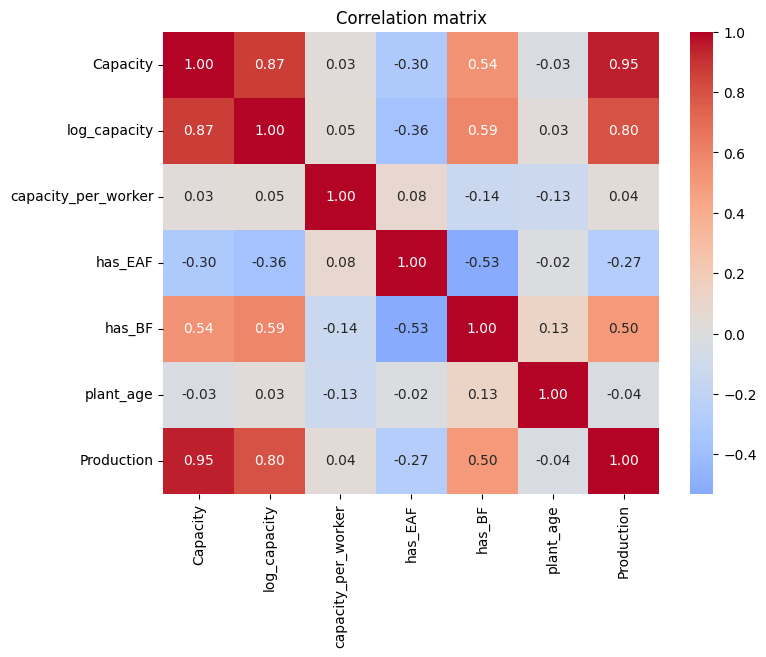

Capacity               0.946762
log_capacity           0.796959
has_BF                 0.495576
has_EAF               -0.271169
plant_age             -0.038989
capacity_per_worker    0.037166
Name: Production, dtype: float64

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_feat[numeric_cols + [target_col]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

corr[target_col].drop(target_col).sort_values(key=abs, ascending=False)

> 📝 *Critical thinking:*
> Which variables show the strongest correlation with production?
> Do any features appear redundant or highly correlated with each other?


**Answer.** Capacity is by far the strongest driver of production (r = 0.95), followed by log-capacity (0.80) and `has_BF` (0.50): integrated BF-BOF plants are bigger. `has_EAF` is negatively correlated (−0.27), since EAF mini-mills are smaller. Plant age and capacity per worker are almost uncorrelated with production (|r| < 0.05). Redundant pairs: `Capacity` vs `log_capacity` (0.87), and `has_BF` vs `Capacity`/`log_capacity` (0.54–0.59) and vs `has_EAF` (−0.53). This collinearity makes linear coefficients harder to read, which is one reason to also test Ridge.

## 🧮 2. Building Baseline & Linear Models

### 🧭 Objective
Establish a simple baseline, then train and interpret a linear model.

---

### **Task 2.1 – Baseline**
- Compute a simple baseline predictor (mean or median production) with `sklearn.dummy.DummyRegressor`. Report RMSE and MAE on the held-out test set.
- Build a second baseline as a pipeline, using **one** of the following. Fit preprocessing on the training split only (inside the pipeline, not on the full table):
  - **scikit-learn:** a `Pipeline` with preprocessing (`ColumnTransformer`: impute, encode categoricals, scale numerics) and a default regressor.
  - **skrub:** [`tabular_pipeline("regressor")`](https://skrub-data.org/stable/reference/generated/skrub.tabular_pipeline.html), which wires a `TableVectorizer` to an estimator-appropriate preprocessor.
- Compare the pipeline’s RMSE and MAE with the dummy baseline.


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def scores(y_true, y_pred):
    return {"RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAE": mean_absolute_error(y_true, y_pred),
            "R2": r2_score(y_true, y_pred)}

X = df_feat[numeric_cols + categorical_cols]
y = df_feat[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dummy = DummyRegressor(strategy="median").fit(X_train, y_train)

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_cols),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols),
])

pipe = Pipeline([("prep", preprocess), ("model", RandomForestRegressor(random_state=42))])
pipe.fit(X_train, y_train)

pd.DataFrame({"Dummy (median)": scores(y_test, dummy.predict(X_test)),
              "Pipeline + RF": scores(y_test, pipe.predict(X_test))}).T.round(2)

,RMSE,MAE,R2
Dummy (median),2982.88,1615.13,-0.16
Pipeline + RF,840.76,582.90,0.91


> 📝 *Critical thinking:*
> Why is it useful to have a baseline model before trying more complex ones?
> Did your pipeline beat the dummy baseline? If the gap is small, what does that say about the features?


**Answer.** The baseline gives the "no-skill" error: a model must beat it to be useful, and a model that doesn't is a sign of a bug. Our pipeline clearly beats it on the test set: RMSE 841 vs 2,983 ttpa and MAE 583 vs 1,615, with R² 0.91 vs −0.16. The gap is large, so the features, capacity above all, carry real information about production. A small gap would have meant the features barely explain production beyond the typical plant.

### **Task 2.2 – Linear Regression**
- Train a multiple linear regression model using the key plant variables.
- Display coefficients and interpret their meaning.
- Evaluate the model on training and test data.


In [33]:
from sklearn.linear_model import LinearRegression

lr_pipe = Pipeline([("prep", preprocess), ("model", LinearRegression())])
lr_pipe.fit(X_train, y_train)

display(pd.DataFrame({"train": scores(y_train, lr_pipe.predict(X_train)),
                      "test": scores(y_test, lr_pipe.predict(X_test))}).T.round(2))

feature_names = lr_pipe.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(lr_pipe.named_steps["model"].coef_, index=feature_names).sort_values()
print(coefs.round(1).to_string())   # numeric: effect (ttpa) of +1 std | categories: shift vs the average plant

,RMSE,MAE,R2
train,875.83,517.13,0.91
test,775.93,529.90,0.92


cat__Status_mothballed pre-retirement   -1039.0
cat__Region_Europe                       -351.7
num__log_capacity                        -228.8
cat__Region_Central & South America       -86.9
cat__Region_Eurasia                       -85.3
cat__Status_retired                       -38.7
cat__Region_Africa                        -20.6
cat__Region_North America                  -8.2
cat__Status_mothballed                     17.8
num__capacity_per_worker                   45.4
cat__Region_Asia Pacific                   54.1
num__plant_age                             75.5
num__has_EAF                               84.8
num__has_BF                                86.8
cat__Status_operating pre-retirement      372.9
cat__Region_Middle East                   498.7
cat__Status_operating                     687.0
num__Capacity                            2859.1


> 📝 *Critical thinking:*
> Interpret one positive and one negative coefficient. What do they tell you about plant performance drivers?


Train R² 0.91 and test R² 0.92 (RMSE 876 vs 776): no overfitting.

**Answer.** **Positive:** `Capacity` (+2,859 ttpa per +1 std, ≈ 3,400 ttpa of capacity): size is the main driver, and plants produce a fairly stable share of their capacity. **Negative:** `Status = mothballed pre-retirement` (−1,039 ttpa vs the average plant): plants being wound down produce far less than their capacity suggests, so status captures utilisation that capacity alone can't. `Region = Europe` (−352) points the same way: lower utilisation of European plants. Note that `log_capacity` is negative only because it overlaps with `Capacity` (r = 0.87); the two should be read together.

## 🔁 3. Model Evaluation and Selection

### 🧭 Objective
Use cross-validation to estimate generalization performance and compare multiple model types.

---

### **Task 3.1 – Cross-Validation**
- Apply **K-Fold cross-validation** (e.g., K=5).
- Record the average RMSE, MAE, and R² across folds.


In [34]:
from sklearn.model_selection import KFold, cross_validate

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error", "r2": "r2"}

# CV on the training split only; the test set stays untouched until the end
cv_results = cross_validate(lr_pipe, X_train, y_train, cv=kf, scoring=scoring)
folds = pd.DataFrame({"RMSE": -cv_results["test_rmse"], "MAE": -cv_results["test_mae"], "R2": cv_results["test_r2"]})
display(folds.round(2))
folds.agg(["mean", "std"]).round(2)

,RMSE,MAE,R2
0,1072.87,582.25,0.71
1,888.91,584.21,0.72
2,692.97,470.39,0.92
3,1185.95,769.94,0.93
4,1229.31,577.37,0.75


,RMSE,MAE,R2
mean,1014.00,596.83,0.80
std,222.54,108.06,0.11


> 📝 *Critical thinking:*
> Summarize your results. How stable is performance across folds? What might this indicate about model variance?


**Answer.** Linear regression averages RMSE 1,014 ± 223 ttpa, MAE 597 and R² 0.80 over the 5 folds. R² ranges from 0.71 to 0.93 across folds, so performance is only moderately stable. With just 216 training plants and a very skewed target, the result depends a lot on which very large plants fall in each fold: one big plant badly predicted inflates RMSE. This points to some variance due to the small sample rather than a model that is too complex.

### **Task 3.2 – Model Comparison**
Train and compare at least **three models**, on the same folds and metrics as Task 3.1:
- Linear Regression
- Ridge Regression (regularized linear)
- Random Forest Regressor

Record cross-validation performance for each model.

**Bonus — tabular foundation model:** add [TabFM](https://github.com/google-research/tabfm) v1.0 (Google Research). Install the PyTorch extra from that repo, then:

```python
from tabfm import TabFMRegressor
from tabfm import tabfm_v1_0_0_pytorch as tabfm_v1_0_0

reg = TabFMRegressor(model=tabfm_v1_0_0.load(model_type="regression"))
```

`fit` stores the training rows as context; `predict` is one forward pass, with no hyperparameter search. The default context is 100 rows (`max_num_rows`). A single held-out split is enough. Pretrained weights are non-commercial and not for production. In the results table, say whether it beats your best classical model, and which model you would actually deploy. Python 3.11 or newer is required.


In [35]:
from sklearn.linear_model import Ridge

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(random_state=42),
}

results = []
for name, model in models.items():
    pipe_i = Pipeline([("prep", preprocess), ("model", model)])
    cv_i = cross_validate(pipe_i, X_train, y_train, cv=kf, scoring=scoring)
    results.append({"model": name, "RMSE": -cv_i["test_rmse"].mean(), "RMSE std": cv_i["test_rmse"].std(),
                    "MAE": -cv_i["test_mae"].mean(), "R2": cv_i["test_r2"].mean()})

results_df = pd.DataFrame(results).set_index("model").sort_values("RMSE")
results_df.round(2)

,RMSE,RMSE std,MAE,R2
model,,,,
Ridge,1009.12,206.39,591.60,0.81
LinearRegression,1014.00,199.05,596.83,0.80
RandomForest,1259.43,641.99,665.16,0.75


> 📝 *Critical thinking:*
> Create a small results table. Which model performs best? Why might that be the case given the dataset’s characteristics?


| Model | CV RMSE | RMSE std | MAE | R² |
|---|---|---|---|---|
| Ridge | 1,009 | 206 | 592 | 0.81 |
| Linear Regression | 1,014 | 199 | 597 | 0.80 |
| Random Forest | 1,259 | 642 | 665 | 0.75 |

**Answer.** **Ridge** performs best, almost tied with linear regression. Production is close to linear in capacity (r = 0.95), so a linear model captures the main relationship, and Ridge's small penalty helps with the collinear features. Random Forest does worse and is much less stable (RMSE std 642): with only ~216 plants, trees can't extrapolate beyond the largest plants seen in training, so a very large plant in a validation fold gets badly under-predicted. On the single test split RF looks better (RMSE 841), but cross-validation is the more reliable comparison.

### **Task 3.3 – Hyperparameter Optimization**
- Use **RandomizedSearchCV** or **GridSearchCV** to tune the top model (e.g., Random Forest).
- Report the best parameters and corresponding validation score.


In [36]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": [1.0, 0.7, "sqrt"],
}
rf_pipe = Pipeline([("prep", preprocess), ("model", RandomForestRegressor(random_state=42))])
search = RandomizedSearchCV(rf_pipe, param_dist, n_iter=20, cv=kf,
                            scoring="neg_root_mean_squared_error", random_state=42, n_jobs=-1)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print(f"Best CV RMSE: {-search.best_score_:.1f}  (untuned RF: {results_df.loc['RandomForest', 'RMSE']:.1f})")
pd.DataFrame({"Tuned RF": scores(y_test, search.best_estimator_.predict(X_test)),
              "Default RF": scores(y_test, pipe.predict(X_test))}).T.round(2)

Best params: {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 0.7, 'model__max_depth': 20}
Best CV RMSE: 1251.1  (untuned RF: 1259.4)


,RMSE,MAE,R2
Tuned RF,884.64,598.38,0.90
Default RF,840.76,582.90,0.91


> 📝 *Critical thinking:*
> Discuss the role of hyperparameter tuning. How did tuning change your model’s performance compared to default settings?


**Answer.** Tuning looks for the settings that control model complexity (number of trees, depth, leaf size, features per split) to balance bias and variance, using cross-validation on the training set only. RandomizedSearch found `n_estimators=300, max_depth=20, min_samples_split=10, min_samples_leaf=2, max_features=0.7`, reducing CV RMSE only slightly, from 1,259 to 1,251. On the test set it is even marginally worse (885 vs 841). Random Forest defaults are already reasonable: the limit here is the small, skewed dataset, not the hyperparameters. Tuning did not make RF beat Ridge.

## ⚙️ 4. Model Lifecycle: Tracking, Saving, and Loading

### 🧭 Objective
Apply tools that support reproducible ML experiments.

---

### **Task 4.1 – Experiment Tracking with MLflow**
- Use MLflow to log parameters (model type, hyperparameters), metrics (RMSE, R²), and artifacts (a plot, the feature list, or your Pandera schema).
- Run and record at least two experiments (for example the Task 2.1 baseline and your best model).


In [37]:
import os, json
import logging
import mlflow, mlflow.sklearn
logging.getLogger("mlflow").setLevel(logging.ERROR)

import sqlite3, shutil
from contextlib import closing
from pathlib import Path
from urllib.parse import urlparse
from urllib.request import url2pathname

# MLflow stores absolute folder paths in its database. A database copied from another computer
# (e.g. "/Users/alixbauret/...") causes "PermissionError: Access denied".
# -> if the store was created on another machine, it is set aside and a fresh one is created here.
DB = Path("mlflow_lab2.db")

def created_here(loc):
    path = Path(url2pathname(urlparse(loc).path)) if loc.startswith("file:") else Path(loc)
    return path.parents[1].exists()          # the project folder that holds mlruns/<id>

if DB.exists():
    with closing(sqlite3.connect(DB)) as con:
        locs = [r[0] for r in con.execute("SELECT artifact_location FROM experiments")]
    if not all(created_here(l) for l in locs):
        DB.rename(DB.with_suffix(".from_other_computer.db"))
        shutil.rmtree("mlruns", ignore_errors=True)
        print("MLflow store came from another computer -> starting a fresh one")

mlflow.set_tracking_uri(f"sqlite:///{DB}")
mlflow.set_experiment("gist-steel-production")

os.makedirs("artifacts", exist_ok=True)
with open("artifacts/features.json", "w") as f:
    json.dump({"numeric": numeric_cols, "categorical": categorical_cols, "target": "Production 2023"}, f, indent=2)
with open("artifacts/pandera_schema.yaml", "w") as f:
    f.write(schema.to_yaml())

def log_run(name, pipe, params):
    with mlflow.start_run(run_name=name):
        pipe.fit(X_train, y_train)
        s = scores(y_test, pipe.predict(X_test))
        mlflow.log_params(params)
        mlflow.log_metrics({"rmse": s["RMSE"], "mae": s["MAE"], "r2": s["R2"]})
        mlflow.log_artifact("artifacts/features.json")
        mlflow.log_artifact("artifacts/pandera_schema.yaml")
        mlflow.sklearn.log_model(pipe, name="model", serialization_format="cloudpickle")
    return s

runs = {
    "baseline": log_run("baseline", Pipeline([("prep", preprocess), ("model", DummyRegressor(strategy="median"))]), {"model": "Dummy"}),
    "ridge": log_run("ridge", Pipeline([("prep", preprocess), ("model", Ridge(alpha=1.0))]), {"model": "Ridge", "alpha": 1.0}),
    "best_rf": log_run("best_rf", search.best_estimator_, {"model": "RandomForest", **search.best_params_}),
}
pd.DataFrame(runs).T.round(2)

,RMSE,MAE,R2
baseline,2982.88,1615.13,-0.16
ridge,786.60,532.32,0.92
best_rf,884.64,598.38,0.90


> 📝 *Critical thinking:*
> Describe how MLflow helps manage your experiments. What advantages does it give compared to manual tracking?


**Answer.** MLflow saves every run with its parameters, metrics, artifacts (feature list, Pandera schema) and the model itself in one store, with a timestamp. We can compare runs side by side in `mlflow ui` and reload any model later. Compared to manual tracking (prints, Excel), nothing is lost when a cell is re-run, results can't be mixed up between versions, and each score is tied to the exact features, schema and settings that produced it.

### **Task 4.2 – Hyperparameter Optimization with Optuna**
- Define an Optuna study to optimize one classical model (Ridge or Random Forest). Skip TabFM here.
- Use a fixed budget (about 30 trials) and the same cross-validation metric as Task 3.
- Record the number of trials, the best parameters, and the score next to the untuned score from Task 3.2.
- Send the trials to the same store as Task 4.1 with `optuna.integration.MLflowCallback`.


In [38]:
import optuna
from optuna.integration import MLflowCallback
optuna.logging.set_verbosity(optuna.logging.WARNING)

# trials go to the same store AND the same experiment as Task 4.1
mlflc = MLflowCallback(tracking_uri=mlflow.get_tracking_uri(), metric_name="cv_rmse", create_experiment=False)

def objective(trial):
    params = {
        "model__n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "model__max_depth": trial.suggest_int("max_depth", 3, 30),
        "model__min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "model__min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
        "model__max_features": trial.suggest_float("max_features", 0.3, 1.0),
    }
    pipe_trial = Pipeline([("prep", preprocess), ("model", RandomForestRegressor(random_state=42))]).set_params(**params)
    cv_scores = cross_validate(pipe_trial, X_train, y_train, cv=kf, scoring="neg_root_mean_squared_error")
    return -cv_scores["test_score"].mean()

study = optuna.create_study(direction="minimize", study_name="rf_optuna", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, callbacks=[mlflc])

print("Best params:", study.best_params)
pd.DataFrame({
    "CV RMSE": [results_df.loc["RandomForest", "RMSE"], -search.best_score_, study.best_value],
    "Trials": [1, 20, len(study.trials)],
}, index=["RF untuned (3.2)", "RF RandomizedSearch (3.3)", "RF Optuna (4.2)"]).round(1)

Best params: {'n_estimators': 267, 'max_depth': 16, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 0.9236772490147737}


,CV RMSE,Trials
RF untuned (3.2),1259.4,1
RF RandomizedSearch (3.3),1251.1,20
RF Optuna (4.2),1230.3,30


> 📝 *Critical thinking:*
> Explain what Optuna is doing behind the scenes. How is it different from Grid or Random Search?


**Answer.** Optuna runs a **TPE sampler** (Bayesian optimisation): after each trial it models which parameter values gave low vs high RMSE and picks the next trial where good results are most likely. Grid Search tests every combination blindly and Random Search samples each trial independently; Optuna learns from past trials and handles continuous ranges (e.g. `max_features` between 0.3 and 1.0). Here, with 30 trials, Optuna got the best RF score (CV RMSE 1,230 vs 1,251 for RandomizedSearch with 20 trials and 1,259 untuned), but Ridge (1,009) remains better, so Ridge is the model we save in 4.3.

### **Task 4.3 – Model Storage**
- Save the best **pipeline** (preprocessing and model together), with `joblib` or `mlflow.sklearn.log_model`. Saving the estimator alone drops the encoder and imputer.
- Load the saved pipeline and re-evaluate it on the test set. The score should match the in-memory pipeline.


In [39]:
import joblib

# keep the model with the lowest CV RMSE (Ridge from 3.2 vs tuned Random Forests)
candidates = {
    "Ridge": (results_df.loc["Ridge", "RMSE"], Pipeline([("prep", preprocess), ("model", Ridge(alpha=1.0))])),
    "RF RandomizedSearch": (-search.best_score_, search.best_estimator_),
    "RF Optuna": (study.best_value, Pipeline([("prep", preprocess),
                                              ("model", RandomForestRegressor(random_state=42, **study.best_params))])),
}
best_name = min(candidates, key=lambda k: candidates[k][0])
best_pipe = candidates[best_name][1].fit(X_train, y_train)
print("Saved model:", best_name)

joblib.dump(best_pipe, "best_pipeline.joblib")
loaded_pipe = joblib.load("best_pipeline.joblib")

pd.DataFrame({"in-memory": scores(y_test, best_pipe.predict(X_test)),
              "reloaded": scores(y_test, loaded_pipe.predict(X_test))}).T.round(2)

Saved model: Ridge


,RMSE,MAE,R2
in-memory,786.6,532.32,0.92
reloaded,786.6,532.32,0.92


> 📝 *Critical thinking:*
> Why is it important to store both model parameters and metadata? How would you ensure version control of models in a production setting?


**Answer.** The weights alone can't reproduce a prediction: we also need the preprocessing (imputer, encoder, scaler, which is why we save the whole pipeline), the feature list, the schema, the data version (GIST June 2026, production 2023), library versions and the metrics. Without this metadata we can't tell which model made a prediction or whether new inputs match what it was trained on. In production: code in Git, data versioned by release, models in the MLflow Model Registry with version numbers and stages (staging → production), each version linked to its run, and pinned dependencies (`requirements.txt`).

## 🚀 5. Deployment & Monitoring (Conceptual)

### 🧭 Objective
Reflect on how models transition from training to production and stay reliable over time.

---

### **Task 5.1 – Deployment Planning**

> 📝 *Critical thinking:*
> Describe how you would deploy the **saved pipeline** from Task 4.3 (REST API or batch job). Incoming rows should pass your Pandera schema before `predict`, so serving applies the same columns and checks as training.
> Which metrics would you monitor: error once actual production arrives, and the share of rows rejected by the schema?
> If you tried TabFM, would you deploy it or the classical pipeline? The pretrained weights are non-commercial and not for production use.


**Answer.** GIST is updated a few times a year and production is reported yearly, so we would use a **batch job** (a FastAPI REST endpoint only if another tool needs on-demand predictions). Each run: load the new release → same aggregation as Task 1.1 → Pandera schema → rejected rows go to a quarantine table → `predict` with the saved pipeline (Ridge) → store predictions with the model version. We would monitor (1) the share of rows rejected by the schema, with an alert above ~5 %; (2) RMSE / MAE once actual production is published, compared with our test score; (3) the distribution of inputs (capacity, status, region) and of predictions. We did not try TabFM; even if it scored better we would deploy the classical pipeline, since TabFM weights are non-commercial and not for production.

In [40]:
def predict_new_rows(raw_df, schema, pipeline, feature_cols):
    """Validate incoming rows with the training schema, reject the bad ones, predict the rest."""
    raw_df = raw_df.copy()
    for c in ["Plant age", "Workforce size"]:
        raw_df[c] = pd.to_numeric(raw_df[c], errors="coerce")
    try:
        schema.validate(raw_df, lazy=True)
        bad = []
    except pa.errors.SchemaErrors as err:
        bad = err.failure_cases["index"].dropna().unique().tolist()
    ok = raw_df.drop(index=bad)
    return pd.Series(pipeline.predict(ok[feature_cols]), index=ok.index), len(bad) / len(raw_df)

# demo: 10 plants, one with an impossible capacity
new_rows = df_feat.sample(10, random_state=0).copy()
new_rows.iloc[0, new_rows.columns.get_loc(capacity_col)] = -100
preds, reject_rate = predict_new_rows(new_rows, schema, loaded_pipe, numeric_cols + categorical_cols)
print(f"Rejected by schema: {reject_rate:.0%}")
preds.round(0)

Rejected by schema: 10%


634      1483.0
744      1496.0
860     18170.0
1157     1813.0
915      5273.0
706     11321.0
808       677.0
1160     1445.0
66       2556.0
dtype: float64

### **Task 5.2 – Detecting Model Drift**

> 📝 *Critical thinking:*
> What signs might indicate your model needs retraining?
> Give one example of **data drift** and one of **concept drift** relevant to steel plant production.
> Name one column from your Pandera schema you would watch first, and what shift in that column would count as data drift.


Signs that retraining is needed: error rising once real production arrives, more rows rejected by the schema, inputs or predictions shifting away from the training data, or a systematic bias for one region or technology.
- **Data drift:** decarbonisation shifts the plant mix from BF-BOF to EAF and DRI plants, so the model sees more of a plant type that was rare in training.
- **Concept drift:** the same plant produces less for the same capacity because of Chinese output caps, EU carbon costs (CBAM) or a demand slump; the capacity → production relationship changes.
- **Column to watch first:** Capacity. A significant change in its distribution between training and a new release (KS test p < 0.05, or median capacity moving by more than ~20 %) would count as data drift.

In [41]:
from scipy.stats import ks_2samp

# example drift check on the column we would watch first: capacity (train vs test here, train vs new batch in production)
stat, p = ks_2samp(X_train[capacity_col], X_test[capacity_col])
print(f"KS test on Capacity: statistic={stat:.3f}, p-value={p:.3f} ->", "drift" if p < 0.05 else "no significant drift")

KS test on Capacity: statistic=0.106, p-value=0.689 -> no significant drift


## 💬 6. Feedback

> 📝 *Critical thinking:*
> 1. Which step of the modelling lifecycle did you find most challenging and why?
> 2. What would you do differently if you had access to additional plant-level data?
> 3. How would you communicate model insights to a business audience?


**1. Most challenging step.** Data preparation and feature engineering. The file has one row per unit rather than per plant, production is stored by type and year with text values like "unknown", and several columns mix numbers and text. The hardest part was avoiding leakage: our first version used a utilization ratio (production / capacity) as a feature, which gave an R² of 0.96 that was not real. Once we removed it, the scores dropped to realistic values, which showed us how easily a feature built from the target can make a model look far better than it is.

**2. With more plant-level data.** We would use several years of production per plant (for example last year's output as a lagged feature), plus energy and scrap prices, technology details and country-level demand. We would also predict the utilization rate instead of raw production, since it is less skewed and easier to compare across plants of different sizes.

**3. Communicating to a business audience.** Start with the key message: capacity explains most of production, while technology, status and region explain why some plants run below capacity. Show the typical error in tonnes (MAE) rather than R², use a simple chart of the most important features and a few concrete plant examples, and state clearly what the model cannot predict, such as policy shocks, closures or sudden demand drops.